# Logistic Regression — Pima Indians Diabetes Dataset

## Aim

To implement Logistic Regression for predicting diabetes and compare
the model performance with and without feature scaling.

## Tasks

- Load and preprocess the diabetes dataset.
- Implement Logistic Regression for binary classification.
- Train the model with and without feature scaling.
- Evaluate both models using Accuracy, Precision, Recall and F1-score.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
df = pd.read_csv("diabetes.csv")

print(df.head())
print("Shape:", df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape: (768, 9)


## Dataset

The dataset contains medical measurements and a binary `Outcome` column.

- `Outcome = 0` → No diabetes
- `Outcome = 1` → Diabetes

In [5]:
print(df.info())
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                     

##Train Test Split

In [6]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features:", X.columns.tolist())
print("Target:", "Outcome")

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target: Outcome


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


## Logistic Regression Without Feature Scaling

First, Logistic Regression is trained directly on the original features.
No feature scaling is applied.

In [8]:
model_no_scaling = LogisticRegression(max_iter=1000)

model_no_scaling.fit(X_train, y_train)

y_pred_no_scaling = model_no_scaling.predict(X_test)

In [9]:
accuracy_no = accuracy_score(y_test, y_pred_no_scaling)
precision_no = precision_score(y_test, y_pred_no_scaling)
recall_no = recall_score(y_test, y_pred_no_scaling)
f1_no = f1_score(y_test, y_pred_no_scaling)

print("Without Scaling")
print("----------------")
print("Accuracy :", accuracy_no)
print("Precision:", precision_no)
print("Recall   :", recall_no)
print("F1-score :", f1_no)

Without Scaling
----------------
Accuracy : 0.7077922077922078
Precision: 0.5882352941176471
Recall   : 0.5555555555555556
F1-score : 0.5714285714285714


## Feature Scaling

StandardScaler is used to standardize the features.

Each feature is transformed so that it has approximately:
- Mean = 0
- Standard deviation = 1

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
model_scaling = LogisticRegression(max_iter=1000)

model_scaling.fit(X_train_scaled, y_train)

y_pred_scaling = model_scaling.predict(X_test_scaled)

In [12]:
accuracy_scaled = accuracy_score(y_test, y_pred_scaling)
precision_scaled = precision_score(y_test, y_pred_scaling)
recall_scaled = recall_score(y_test, y_pred_scaling)
f1_scaled = f1_score(y_test, y_pred_scaling)

print("With Scaling")
print("------------")
print("Accuracy :", accuracy_scaled)
print("Precision:", precision_scaled)
print("Recall   :", recall_scaled)
print("F1-score :", f1_scaled)

With Scaling
------------
Accuracy : 0.7077922077922078
Precision: 0.5882352941176471
Recall   : 0.5555555555555556
F1-score : 0.5714285714285714


In [13]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Without Scaling": [
        accuracy_no,
        precision_no,
        recall_no,
        f1_no
    ],
    "With Scaling": [
        accuracy_scaled,
        precision_scaled,
        recall_scaled,
        f1_scaled
    ]
})

print(results)

      Metric  Without Scaling  With Scaling
0   Accuracy         0.707792      0.707792
1  Precision         0.588235      0.588235
2     Recall         0.555556      0.555556
3   F1-score         0.571429      0.571429


## Performance Comparison

The following graph compares Logistic Regression performance
with and without feature scaling.

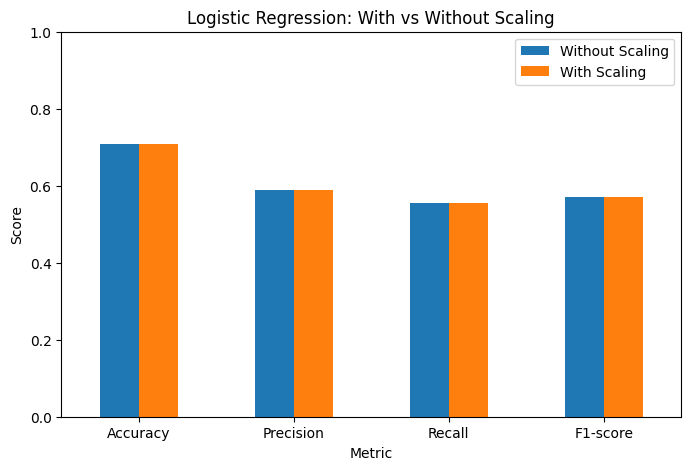

In [15]:
results.set_index("Metric").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Logistic Regression: With vs Without Scaling")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

#Confusion Matrix

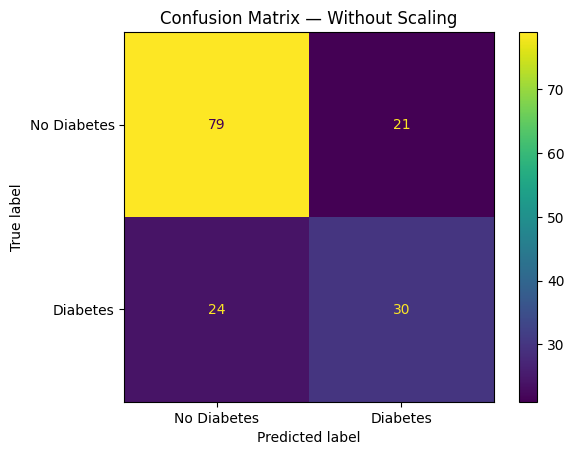

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Without scaling
cm_no = confusion_matrix(y_test, y_pred_no_scaling)

ConfusionMatrixDisplay(
    confusion_matrix=cm_no,
    display_labels=["No Diabetes", "Diabetes"]
).plot()

plt.title("Confusion Matrix — Without Scaling")
plt.show()

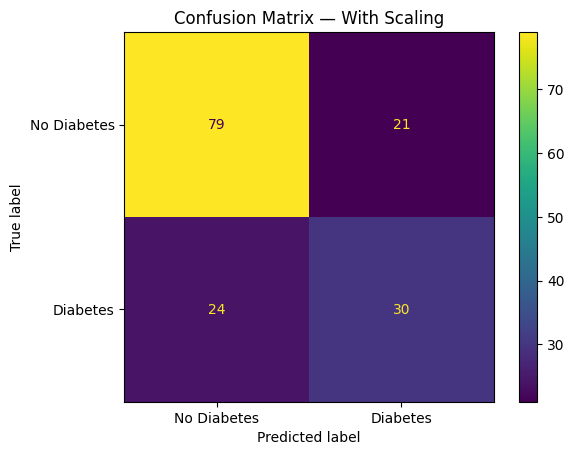

In [17]:
# With scaling
cm_scaled = confusion_matrix(y_test, y_pred_scaling)

ConfusionMatrixDisplay(
    confusion_matrix=cm_scaled,
    display_labels=["No Diabetes", "Diabetes"]
).plot()

plt.title("Confusion Matrix — With Scaling")
plt.show()

## Conclusion

Logistic Regression was implemented with and without feature scaling.

For this dataset and train-test split, both models produced the same
confusion matrix:

- True Negatives = 79
- False Positives = 21
- False Negatives = 24
- True Positives = 30

Therefore, Accuracy, Precision, Recall and F1-score were also the same
for both models.

Although feature scaling did not change the final predictions in this
experiment, scaling is useful for Logistic Regression because it places
features on a comparable scale and can improve the optimization process.